# Segnature Inference

In [8]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [9]:
class ResultsEvaluation:
    
    def __init__(self, file_name):
        self.evaluations_df = json.load(open(f'../results/{file_name}.json'))
        self.run_labels, self.sampling_labels, self.signature_labels = self.get_runs_sample_labels()
        self.per_run_accuracy = self.get_runs_sample_accuracy()
        
    def get_runs_sample_labels(self):
        run_labels = []
        for run in list(self.evaluations_df.keys()):
            if self.evaluations_df[run]['sampling_0.01'] != {}:
                run_labels.append(run)  

        sampling_labels = self.evaluations_df[run_labels[0]].keys()
        sampling_labels = list(sampling_labels)
        signature_labels = []
        for i in range(len(self.evaluations_df[run_labels[0]][sampling_labels[0]])):
            signature_labels.append(self.evaluations_df[run_labels[0]][sampling_labels[0]][i]['signature'])

        return run_labels, sampling_labels, signature_labels
    
    def get_runs_sample_accuracy(self):
        run_labels, sampling_labels, signature_labels = self.get_runs_sample_labels() 
        per_run_accuracy = []
        for run in run_labels:
            per_sample_accuracy = []
            for sampling in sampling_labels:
                per_signature_accuracy = []
                for i in range(len(signature_labels)):
                    per_signature_accuracy.append(self.evaluations_df[run][sampling][i]['best_model_metrics']['balanced_accuracy'])# Save the accuracy of each signarure for one sample

                # Here we have the mean accuracy of all signatures for one sample
                per_sample_accuracy.append(per_signature_accuracy)
            # Here we have the mean accuracy of all samples for one run
            per_run_accuracy.append(per_sample_accuracy)
        return per_run_accuracy

In [10]:
def plot_all_signature_all_sampling_graph(re):
    per_run_accuracy = np.array(re.per_run_accuracy)
    mean_accuracy = np.mean(per_run_accuracy, axis=0)

    plt.figure(figsize=(20, 10))

    # Plotta la media per ogni campione (dimensione j di per_sample_accuracy)
    for j in range(len(mean_accuracy)):
        plt.plot(re.signature_labels, mean_accuracy[j], marker='o', label=re.sampling_labels[j])

    plt.legend(re.sampling_labels)
    plt.xticks(rotation=90)
    plt.ylabel('Average Accuracy')
    plt.xlabel('Signature')
    plt.title('Average Accuracy per Signature (Averaged Across Runs)')

    plt.tight_layout()
    plt.show()
    
def plot_per_run_accuracy(re):
    per_run_mean_accuracy =[]
    for i in range(len(re.per_run_accuracy)):      
        per_sample_mean_accuracy = []
        per_sample_accuracy = re.per_run_accuracy[i]
        for j in range(len(per_sample_accuracy)):
            per_sample_mean_accuracy.append(np.mean(per_sample_accuracy[j]))
        per_run_mean_accuracy.append(per_sample_mean_accuracy)
    print(np.array(per_run_mean_accuracy).shape)
    means = np.array(per_run_mean_accuracy).mean(axis=0)
    plt.plot(re.sampling_labels,means, marker='o')
    plt.xticks(rotation=90)
    
def plot_violins(re):
    plt.figure(figsize=(20, 10))
    per_run_accuracy = np.array(re.per_run_accuracy)
    plt.xlabel('Sampling')
    plt.xticks(range(1, len(re.sampling_labels) + 1), re.sampling_labels, rotation=90)
    plt.ylabel('Accuracy')
    plt.title('Violin Plot of Accuracy Across Runs')
    plt.violinplot([per_run_accuracy[:, j, :].flatten() for j in range(len(re.sampling_labels))], showmeans=True, showmedians=True, showextrema=True)
    

## Plot the graphs

### Statistiche sulle segnature

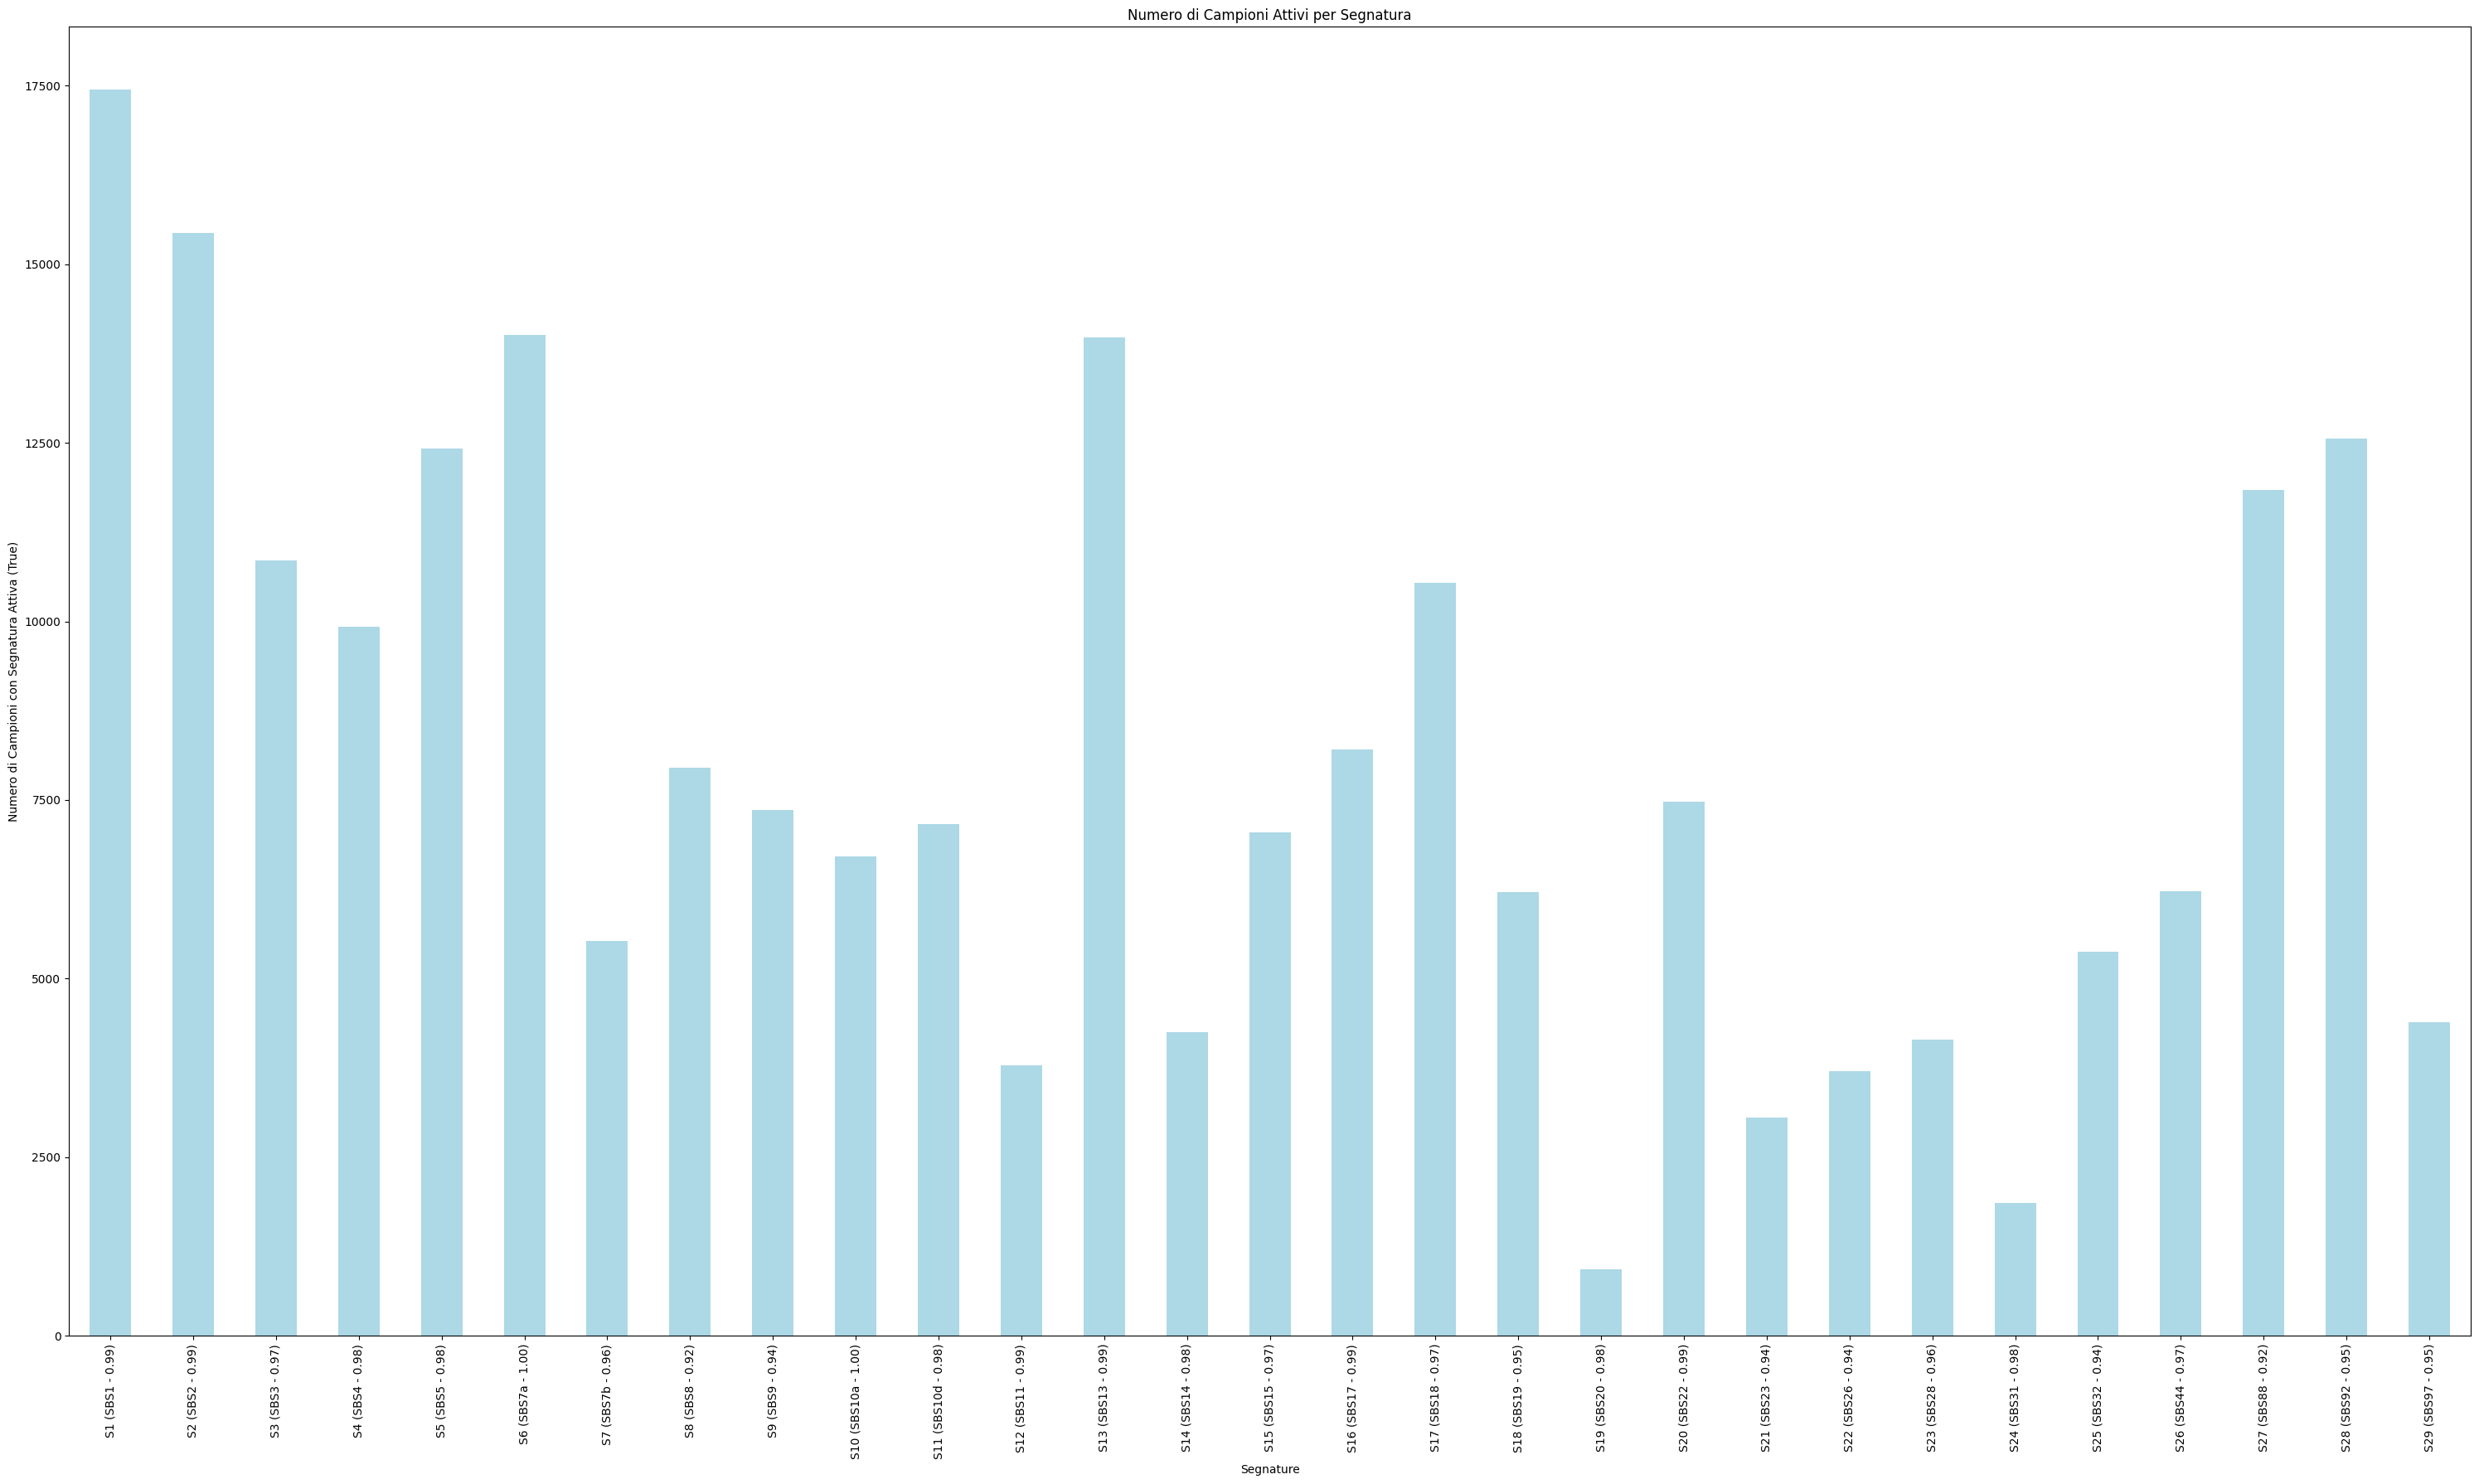

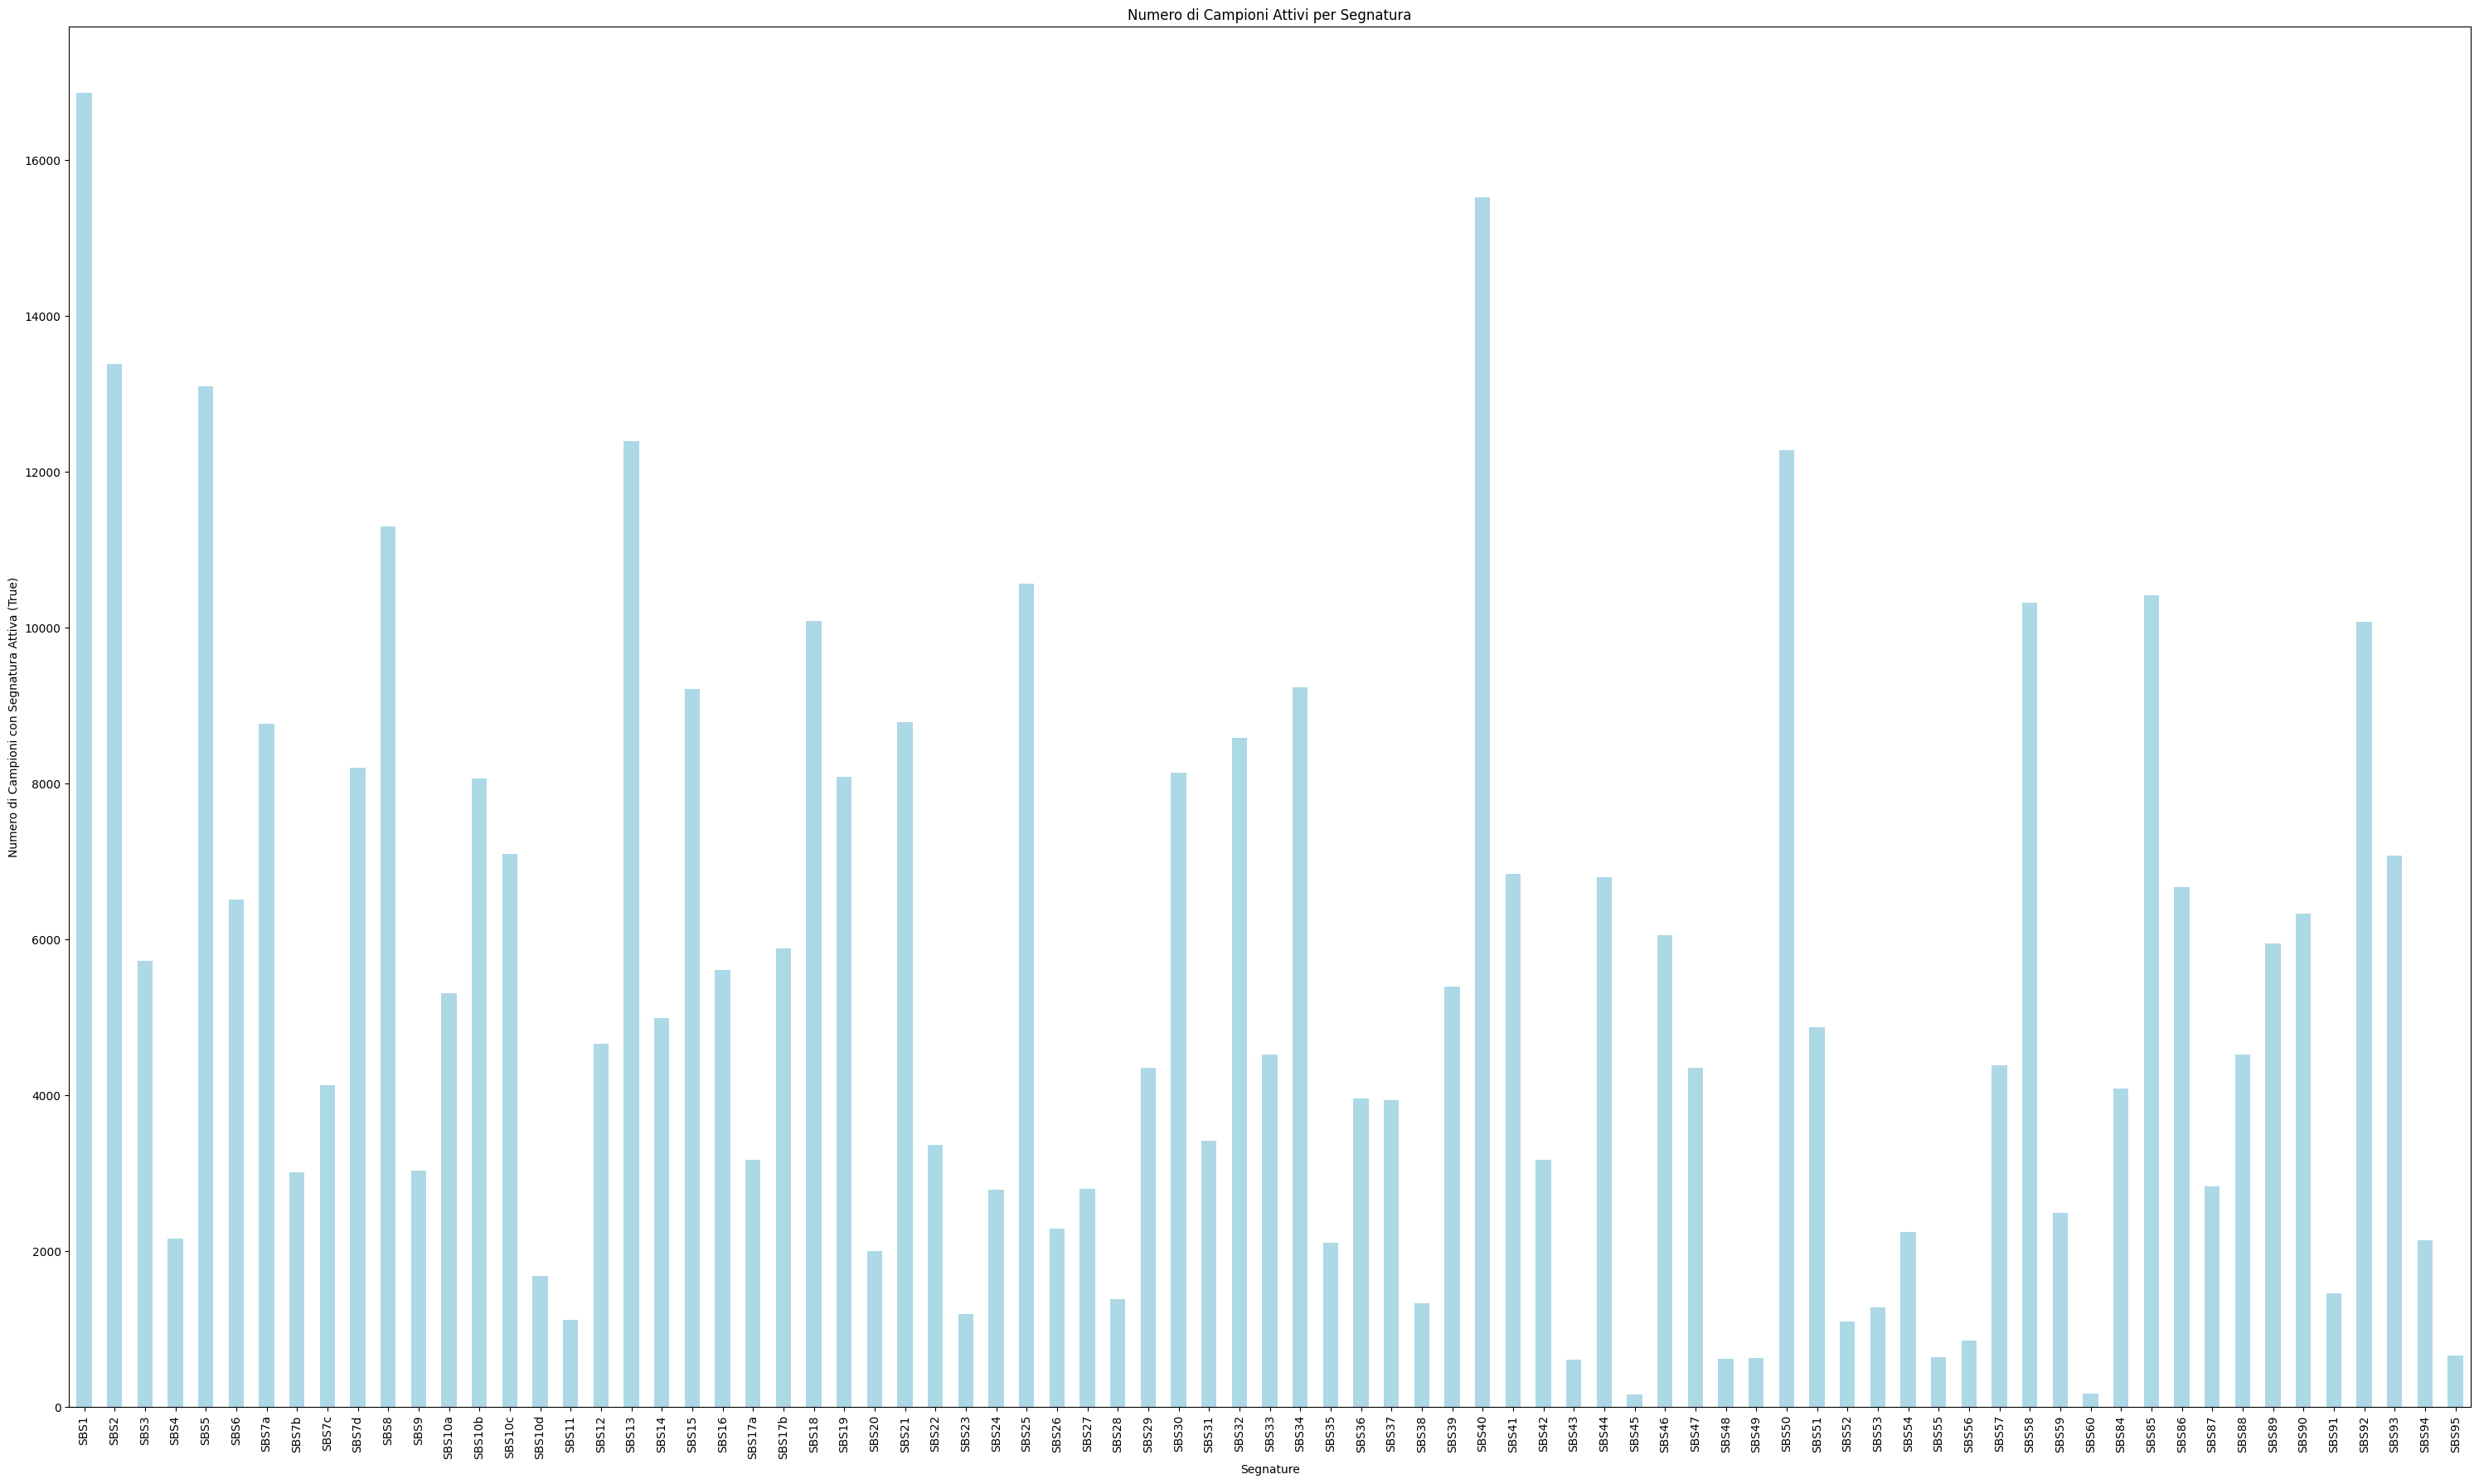

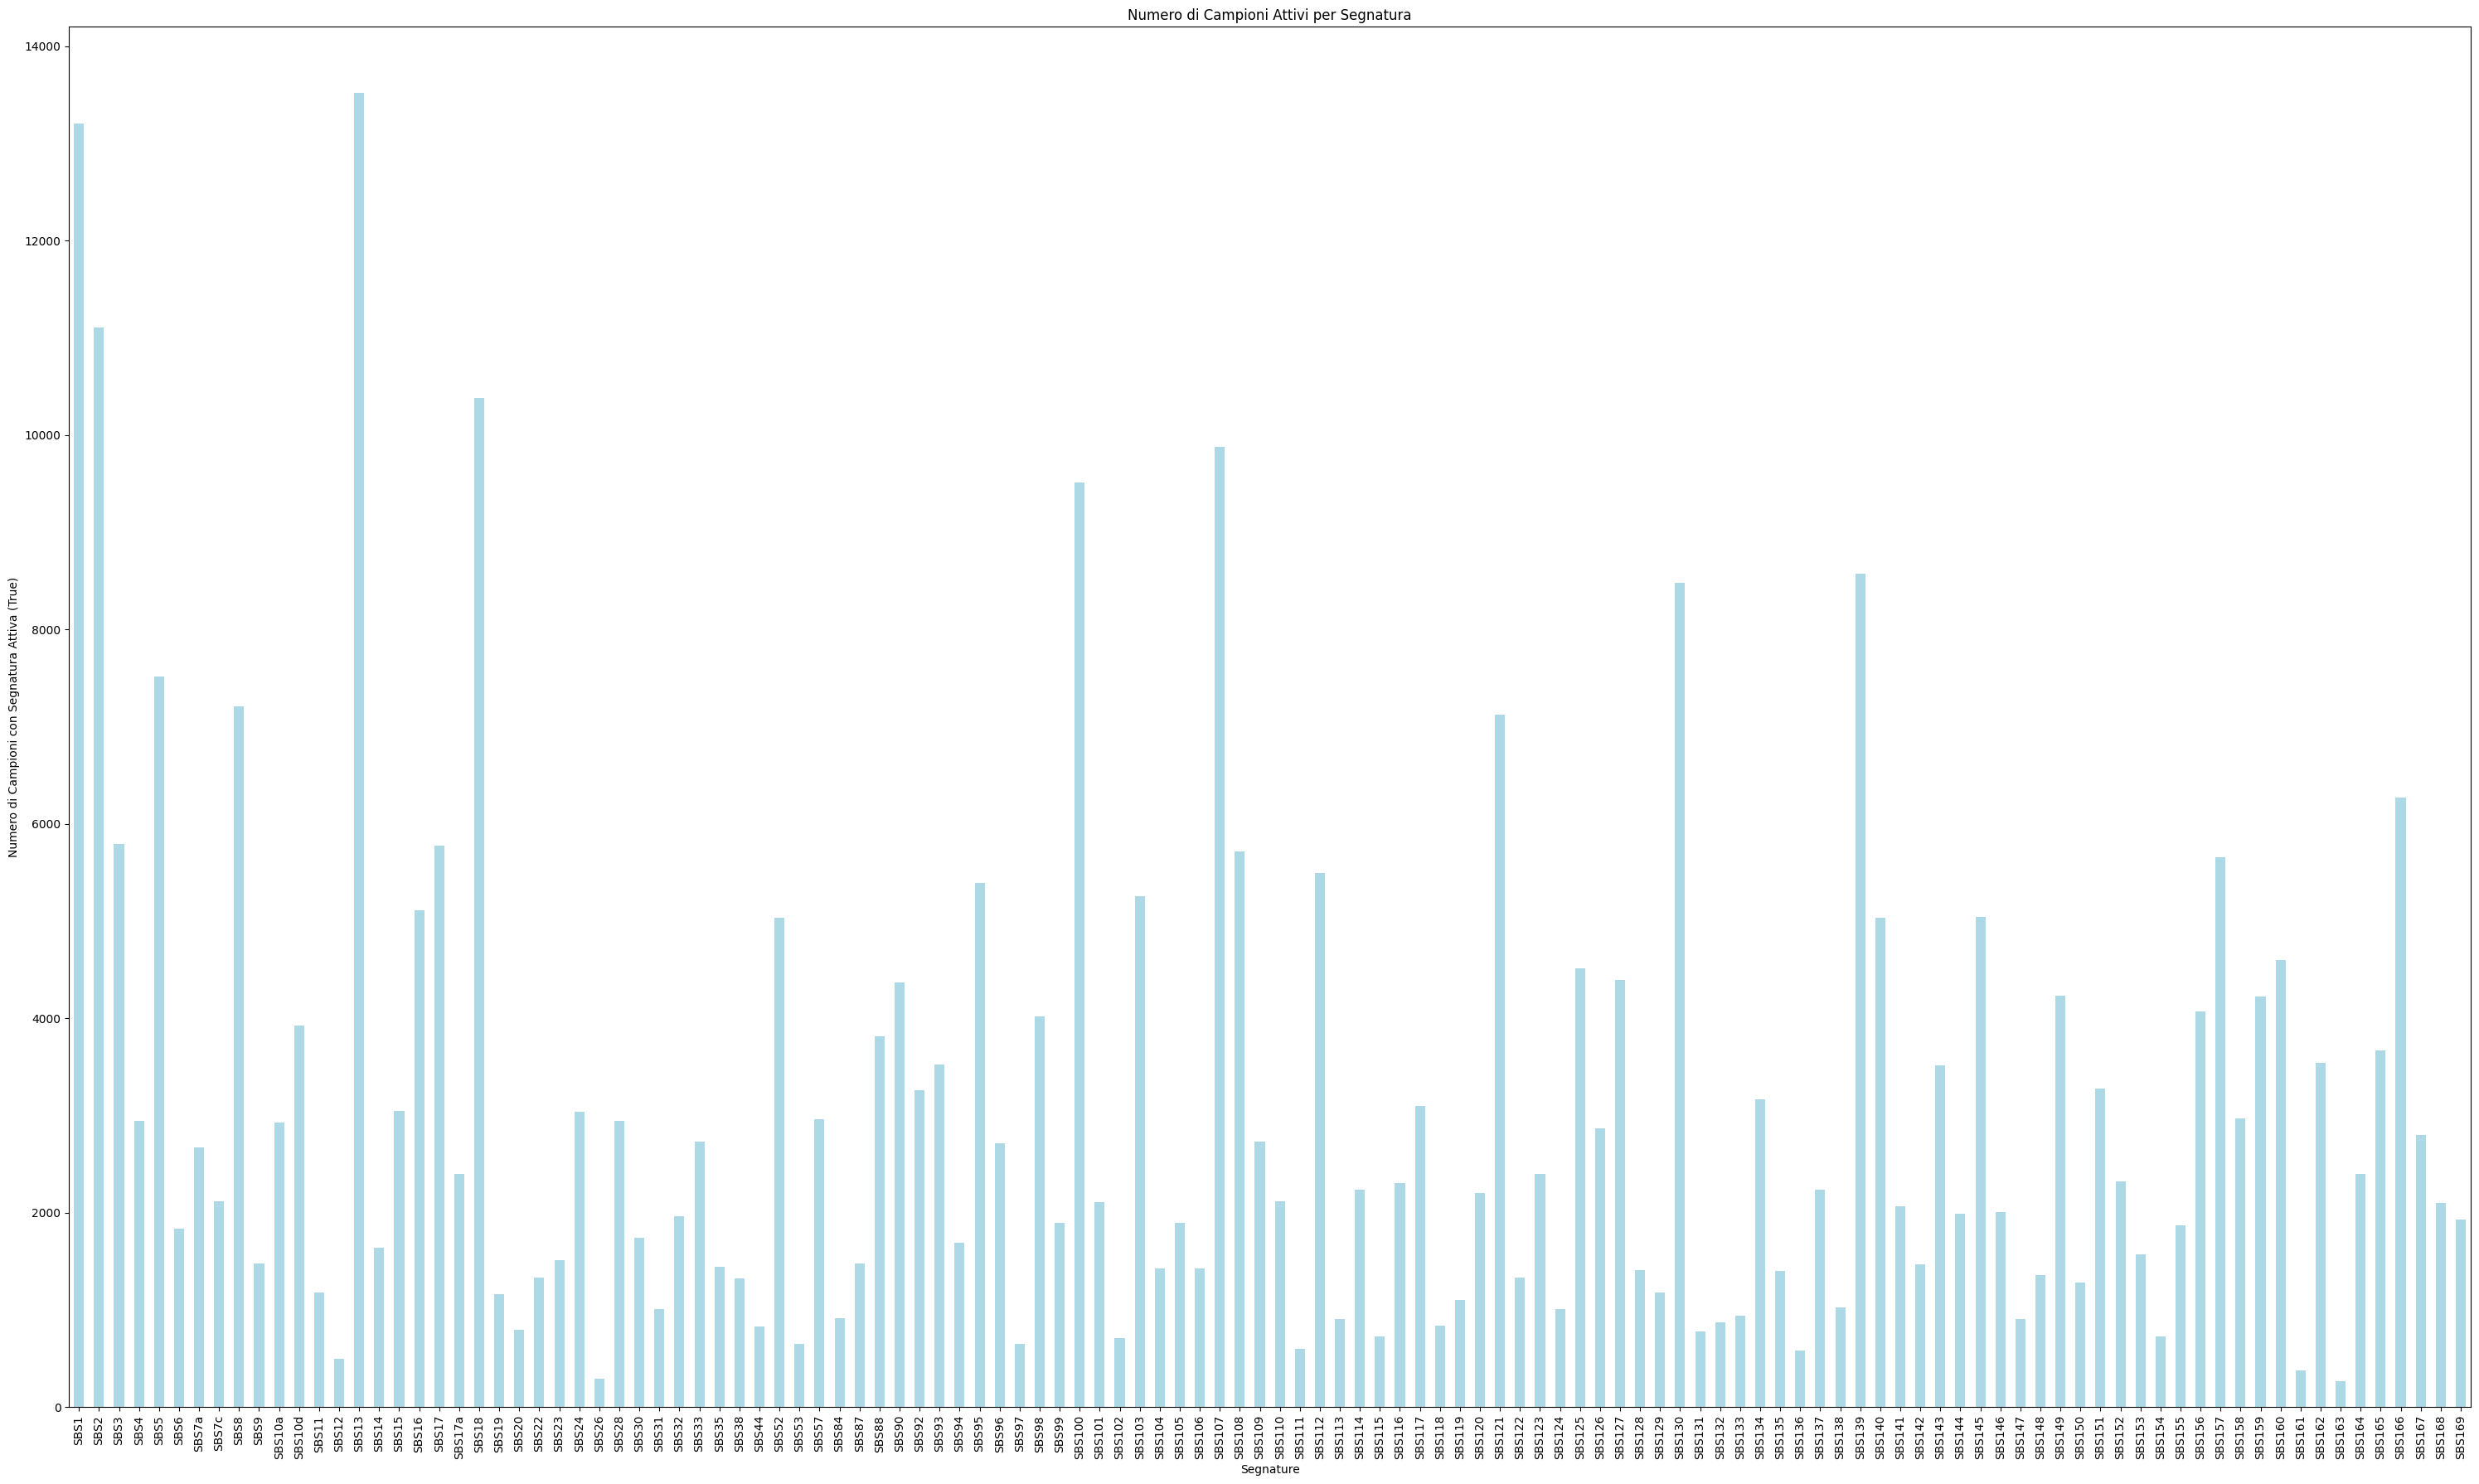

In [11]:
def number_of_sample_per_signature(folder_name):
    signature_gt_path = f'../simulations/ground_truth{folder_name}/bin_exposures.csv'

    signature_gt_df = pd.read_csv(signature_gt_path)
    signature_gt_df.head()

    active_segnature = signature_gt_df.iloc[:, 1:].sum()
    plt.figure(figsize=(30, 18))
    active_segnature.plot(kind='bar', color='lightblue')
    plt.xlabel('Segnature')
    plt.ylabel('Numero di Campioni con Segnatura Attiva (True)')
    plt.title('Numero di Campioni Attivi per Segnatura')
    plt.xticks(rotation=90)  # Ruota le etichette sull'asse X per renderle leggibili
    plt.tight_layout()
    plt.show()
    
number_of_sample_per_signature('')
number_of_sample_per_signature('_cosmic')
number_of_sample_per_signature('_reference')


### Accuratezza per signature, per sample, per run
In questo grafico viene mostrato il livello di accuracy mediato ottenuto per ogni segnatura al variare del livello di sampling, per ogni run

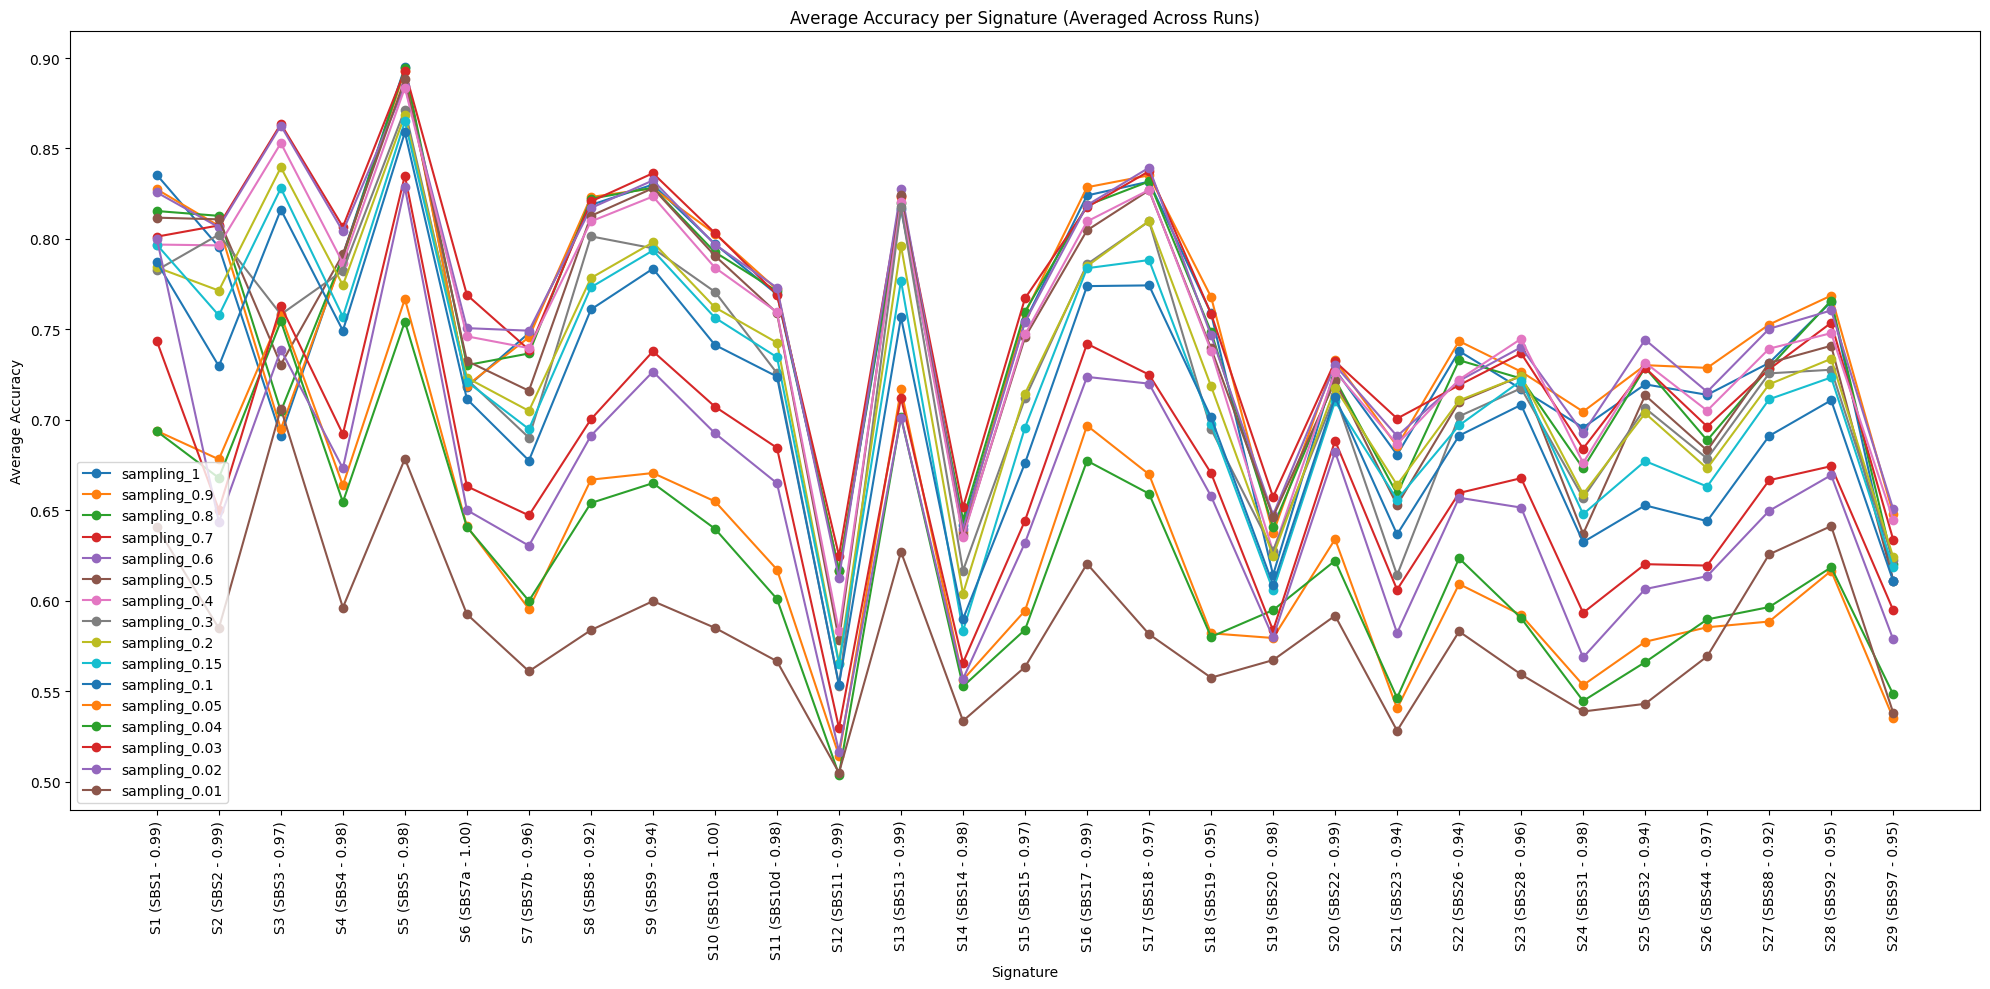

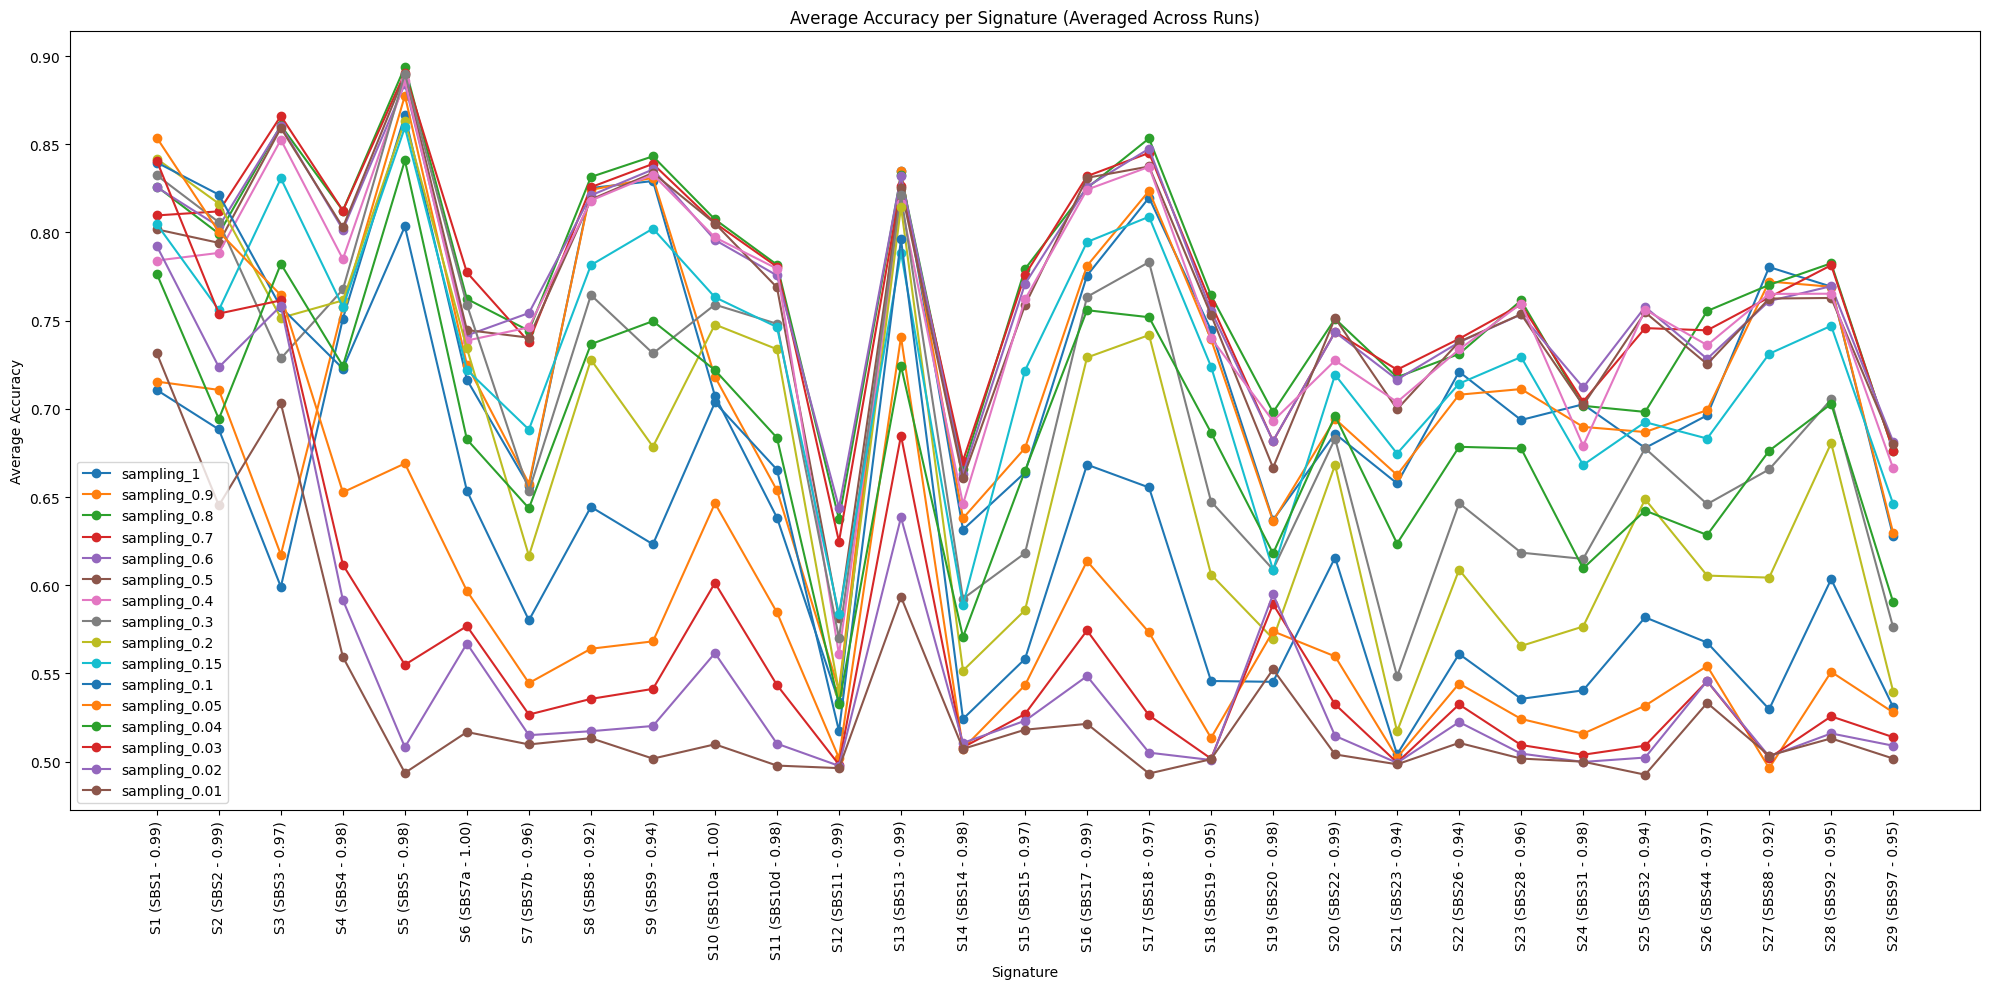

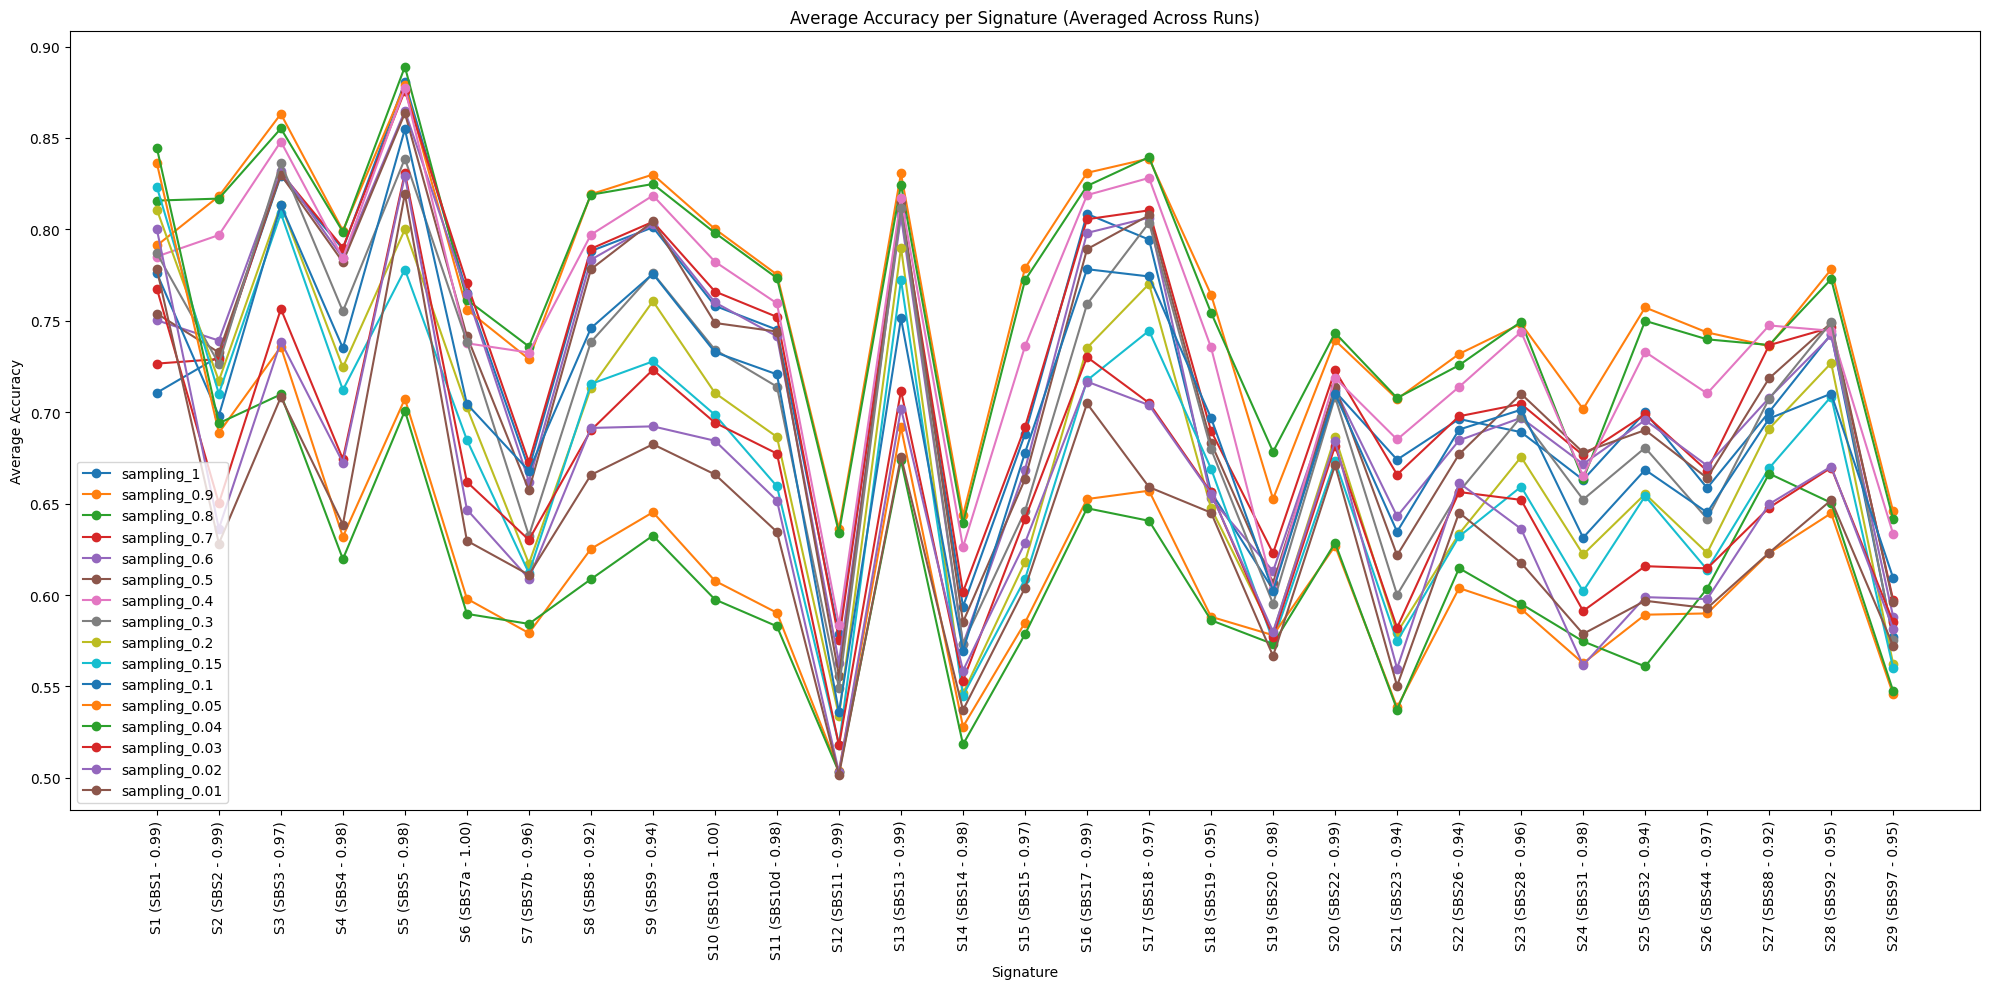

In [12]:
def_corr_rs = ResultsEvaluation('default_correlated_evaluations')
def_uncorr_rs = ResultsEvaluation('default_non_correlated_evaluations')
def_light = ResultsEvaluation('default_light_evaluations')

rss = [def_corr_rs, def_corr_rs, def_light]

plot_all_signature_all_sampling_graph(def_corr_rs)
plot_all_signature_all_sampling_graph(def_uncorr_rs)
plot_all_signature_all_sampling_graph(def_light)

### Accuratezza media per sample per run
In questo grafico venogno 

(2, 16)
(1, 16)
(2, 16)


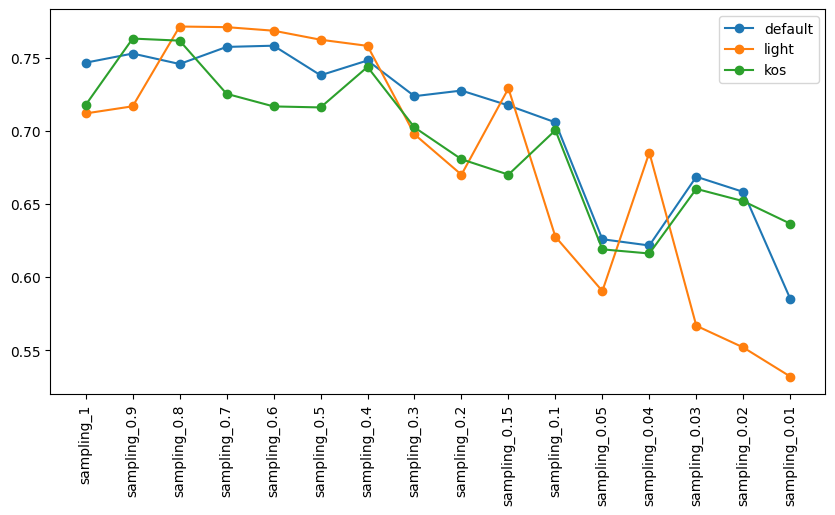

In [13]:
fig = plt.figure(figsize=(10,5))

plot_per_run_accuracy(def_corr_rs)
plot_per_run_accuracy(def_uncorr_rs)
plot_per_run_accuracy(def_light)
plt.legend(['default', 'light', 'kos'])
plt.show()
    # plt.savefig('../evaluations_graphs/toronto_per_sample_average_accuracy_.png')


### Violin-plot

In [14]:
plot_violins(default_rs)
plot_violins(light_rs)
plot_violins(cosmic_rs)

NameError: name 'default_rs' is not defined

# Analysis on the best models

### Best Models

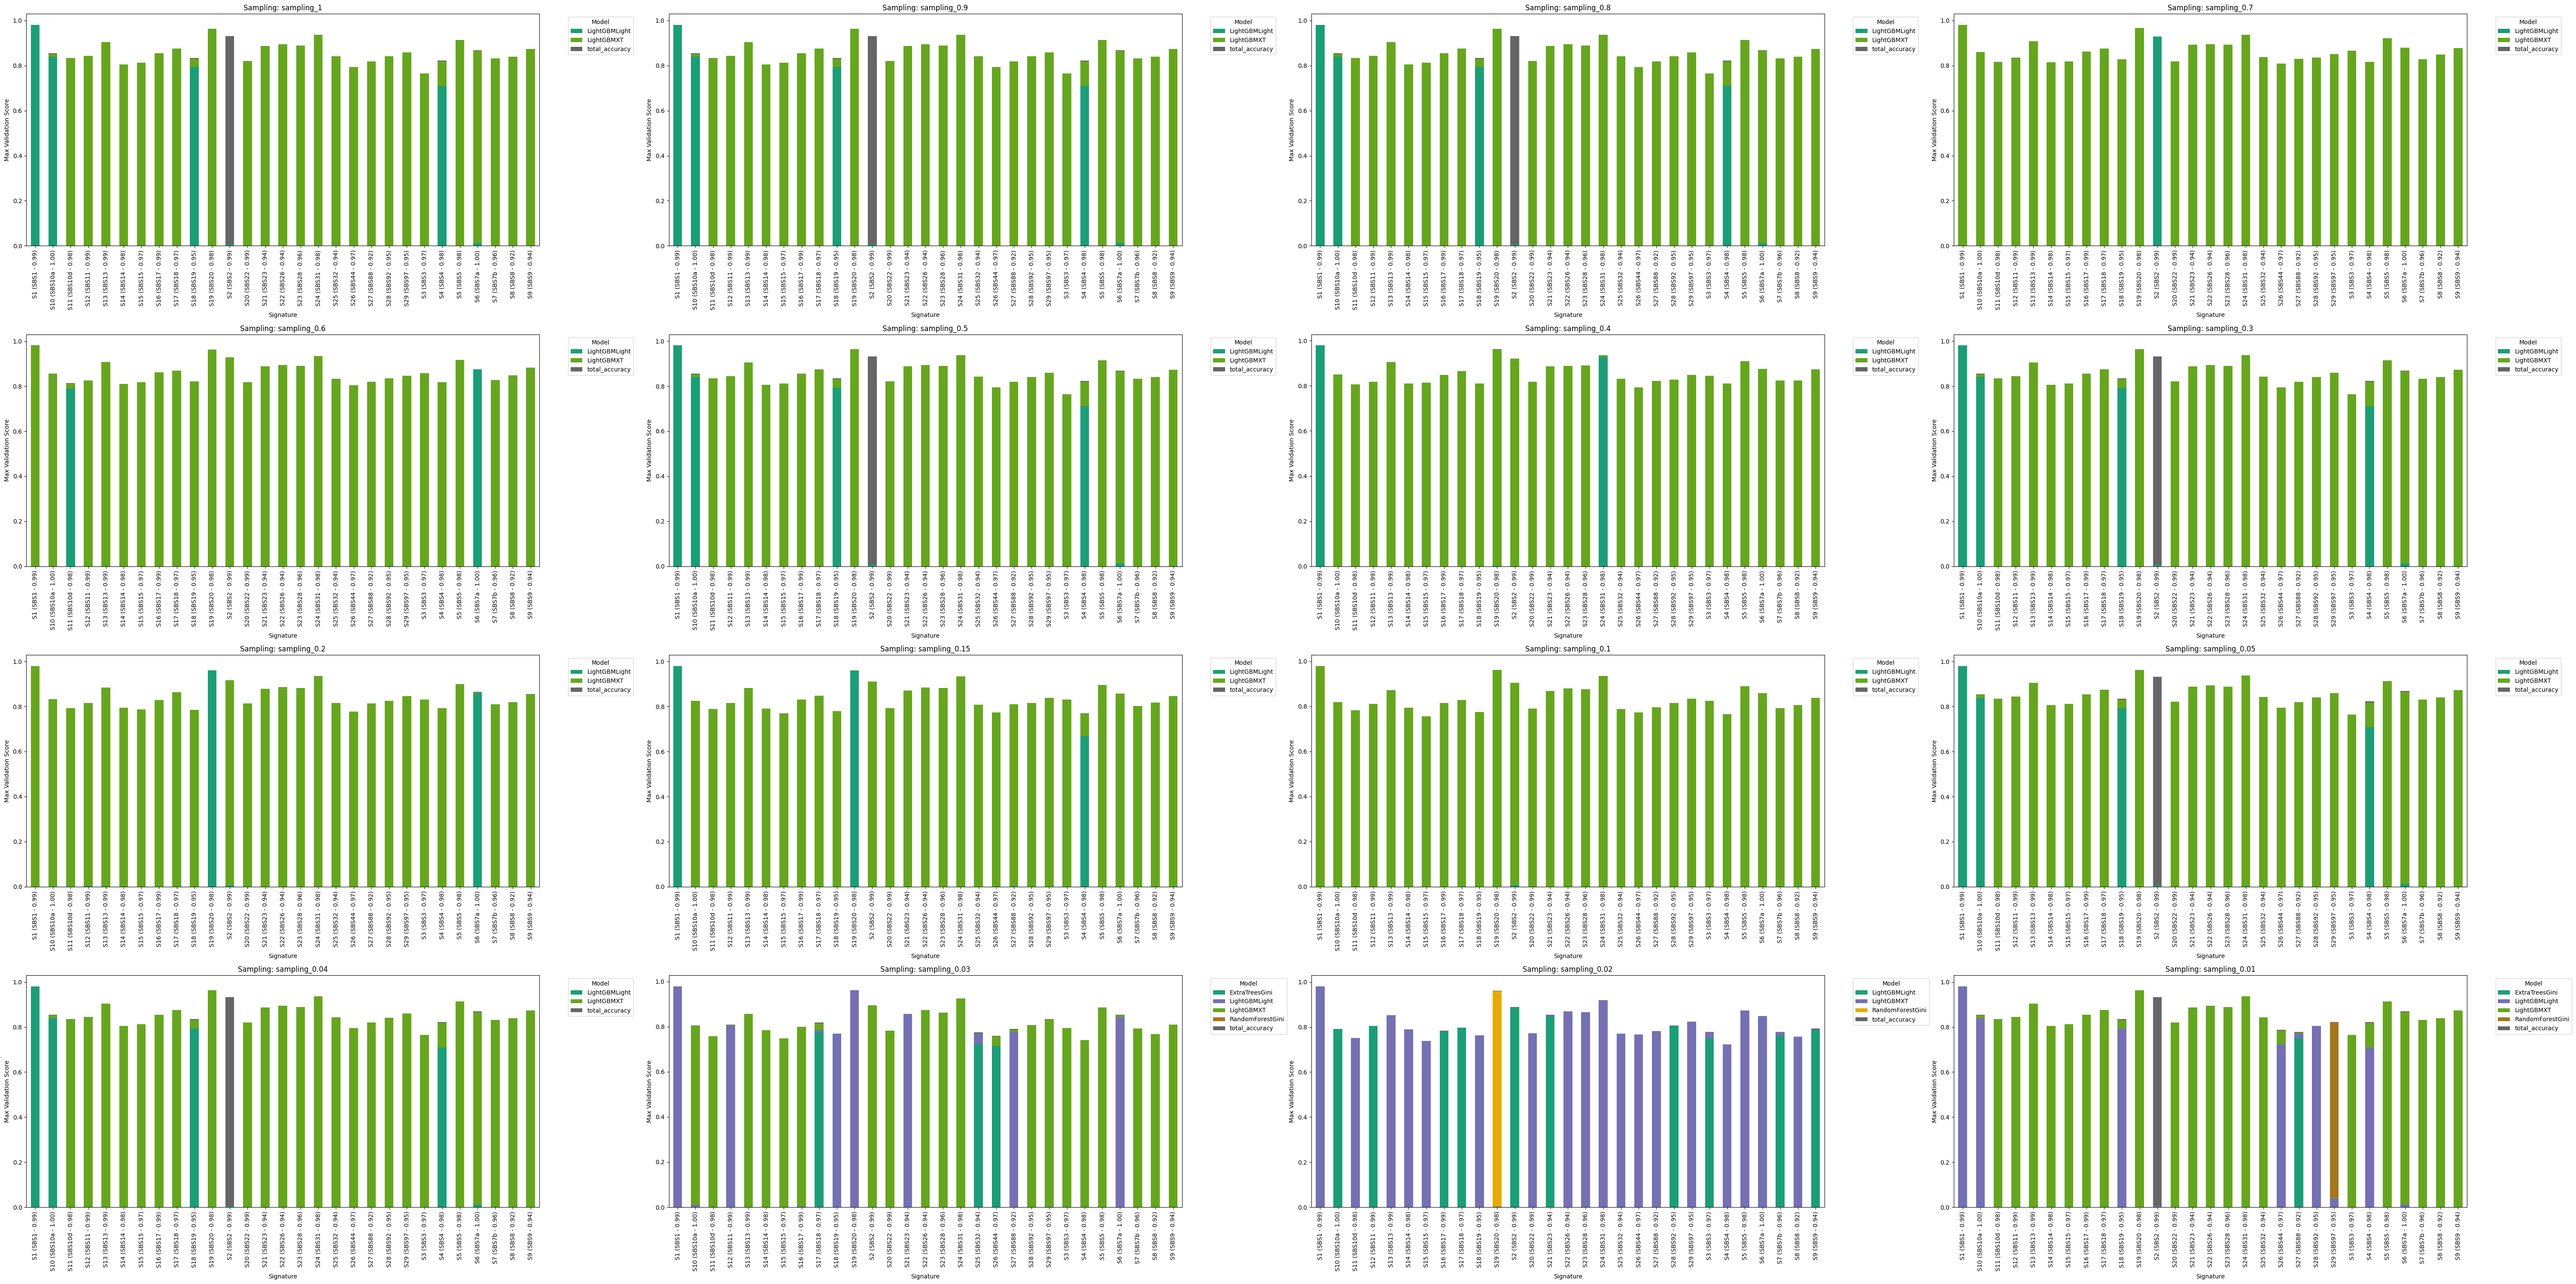

In [15]:
def plot_evaluation_ensamble(er):
    fig, axes = plt.subplots(4, 4, figsize=(60, 30))
    axes = axes.flatten()

    for plot_idx, sampling in enumerate(er.sampling_labels):
        rows = []
        for run in er.run_labels:
            for i, sig in enumerate(er.signature_labels):
                df = pd.DataFrame(er.evaluations_df[run][sampling][i]['ensemble_info'])
                for _, row in df.iterrows():
                    rows.append({
                        'signature': sig,
                        'model': row['model_name'],
                        'val_score': row['val_score']
                    })
                rows.append({
                    'signature': sig,
                    'model': 'total_accuracy',
                    'val_score': er.evaluations_df['run_1'][sampling][i]['best_model_val_score']
            })
            break  # solo il primo run

        # Genera il grafico per il subplot corrente
        df_plot = pd.DataFrame(rows)
        processed = []

        for sig, group in df_plot.groupby('signature'):
            sorted_group = group.sort_values('val_score')
            prev = 0
            for _, row in sorted_group.iterrows():
                height = row['val_score'] - prev
                processed.append({
                    'signature': sig,
                    'model': row['model'],
                    'height': height
                })
                prev = row['val_score']

        df_stacked = pd.DataFrame(processed)
        # Pivot e riordino delle colonne
        df_pivot = df_stacked.pivot_table(index='signature', columns='model', values='height', fill_value=0)
        df_pivot.plot(kind='bar', stacked=True, colormap='Dark2', ax=axes[plot_idx])
        axes[plot_idx].set_title(f"Sampling: {sampling}")
        axes[plot_idx].set_ylabel("Max Validation Score")
        axes[plot_idx].set_xlabel("Signature")
        axes[plot_idx].legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')


    plt.tight_layout()    
plot_evaluation_ensamble(def_corr_rs)
